# BinX AI & ML Internship
## Week 3 - Day 2: Linear Regression

Topics covered:
- What linear regression does (fitting the best line)
- Training and predicting with the Scikit-learn API
- Interpreting coefficients and the intercept
- Regression metrics: MAE, RMSE, R²
- Comparing model performance against a baseline

---

## 1. Linear Regression

### What is Linear Regression?

**Linear Regression** is one of the most fundamental **Supervised Learning** algorithms. It is used to predict a **continuous numerical value** by learning the relationship between one or more input variables (features) and an output variable (target).

Unlike classification, which predicts categories, linear regression predicts numeric values such as prices, salaries, temperatures, or sales.

---

### Definition

Linear Regression predicts a continuous value by fitting the **best-fit straight line** through the data.

The model learns the relationship between the input variables (**features**) and the output (**target**) from the training data, then uses this learned relationship to make predictions for unseen data.

---

### Why is it Called "Linear"?

It is called **Linear Regression** because it assumes that the relationship between the input variables and the target can be approximated by a **straight line**.

If the relationship between variables is approximately linear, the model can make accurate predictions using this line.

---

### Inputs and Outputs

In Linear Regression, there are two main components:

- **Independent Variable (X):** Also called the feature or predictor. It is the input used to make predictions.
- **Dependent Variable (y):** Also called the target or response. It is the value the model tries to predict.

Example:

| Independent Variable (X) | Dependent Variable (y) |
|---------------------------|--------------------------|
| Hours Studied | Exam Score |
| House Size | House Price |
| Years of Experience | Salary |
| Temperature | Ice Cream Sales |

---

### Goal of Linear Regression

The main goal is to learn the relationship between **X** and **y** so the model can accurately predict the target for new data that it has never seen before.

Instead of memorizing every training example, the model learns a general mathematical relationship.

---

### How Does Linear Regression Work?

The model:

1. Receives historical training data.
2. Learns the relationship between features and the target.
3. Finds the line that best represents the data.
4. Uses this learned line to predict continuous values for new inputs.

---

### Characteristics

- Supervised Learning algorithm.
- Used for Regression problems.
- Predicts continuous numerical values.
- Assumes a linear relationship between variables.
- Simple, fast, and highly interpretable.

---

### Common Applications

- House price prediction
- Salary prediction
- Sales forecasting
- Demand prediction
- Stock trend analysis
- Weather prediction
- Medical outcome prediction

---

### Advantages

- Simple to understand and implement.
- Easy to interpret.
- Fast training.
- Works well as a baseline model.
- Widely used in Machine Learning.

---

### Limitations

- Assumes a linear relationship.
- Sensitive to outliers.
- Cannot model complex non-linear relationships effectively.

---

### Key Points

- Linear Regression is a **Supervised Learning** algorithm.
- It predicts **continuous numerical values**.
- It learns the relationship between **features (X)** and the **target (y)**.
- The learned relationship is represented by a **best-fit straight line**.
- After training, the model can predict values for unseen data.

---

## 2. Independent & Dependent Variables

### Independent Variable (X)

The **independent variable(s)**, also called **features** or **predictors**, are the inputs the model uses to make a prediction. They are called "independent" because their values are given — they do not depend on anything else in the equation. There can be one feature or many.

### Dependent Variable (y)

The **dependent variable**, also called the **target** or **response**, is the value the model tries to predict. It is called "dependent" because its value depends on the independent variable(s) — that dependency is exactly what the model is trying to learn.

---

### Simple vs. Multiple Linear Regression

- **Simple Linear Regression:** one independent variable predicting the target.
  Example: `Hours Studied → Exam Score`

- **Multiple Linear Regression:** two or more independent variables predicting the same target.
  Example: `Cylinders, Displacement, Horsepower, Weight, Acceleration, Model Year, Origin → MPG`

The Auto MPG dataset used in this week's Hands-On Lab is an example of **Multiple Linear Regression** — mpg is predicted from 7 features together, not just one.

---

### X and y in Code (illustrative only)

```python
# X: all columns except the target
X = df.drop("mpg", axis=1)

# y: the target column only
y = df["mpg"]
```

---

### Key Points

- Independent variables (X) = inputs / features.
- Dependent variable (y) = output / target — the value being predicted.
- One feature → Simple Linear Regression.
- Multiple features → Multiple Linear Regression (this week's dataset).

---

### Setting Up: Loading the Data

Before visualizing a best-fit line on real data, I load and clean the Auto MPG dataset the same way I did on Day 1 — converting `horsepower` to numeric and dropping the rows where it was missing, then dropping `car name` since it's text, not a usable feature.

**Import Libraries**

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Load & Clean Data**

In [84]:
df = pd.read_csv("data/auto-mpg.csv")

df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna(subset=["horsepower"])
df = df.drop("car name", axis=1)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


---

## 3. Best Fit Line

### What Does "Best Fit" Mean?

Given a scatter of data points, there are infinitely many straight lines that could be drawn through them. Most of those lines would be a poor fit — far from most points. The **best-fit line** is the one specific line that best represents the overall trend in the data: the one that keeps the total prediction error (across every point) as small as possible.

*Exactly how "smallest error" is measured is covered in the next two sections (Least Squares & Residuals, Cost Function).*

### Why Not Just Draw It By Eye?

Estimating a line by eye is subjective — two people would draw it slightly differently, and there is no guarantee it is actually the optimal line. Linear regression instead finds the best-fit line through an exact mathematical procedure, so the result is always the same for the same data.

### Best-Fit Line on Real Data

Below is the best-fit line for **Weight vs. MPG** from the Auto MPG dataset. As a car's weight increases, mpg tends to decrease — the line captures that overall downward trend even though no single point sits exactly on it.

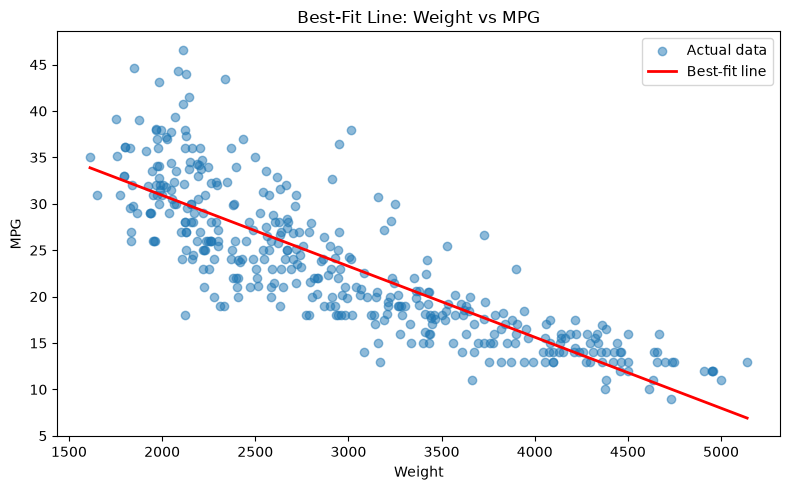

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# quick 1-feature fit, just to visualize the concept of a best-fit line
coeffs = np.polyfit(df["weight"], df["mpg"], 1)
x_line = np.linspace(df["weight"].min(), df["weight"].max(), 100)
y_line = coeffs[0] * x_line + coeffs[1]

plt.figure(figsize=(8, 5))
plt.scatter(df["weight"], df["mpg"], alpha=0.5, label="Actual data")
plt.plot(x_line, y_line, color="red", linewidth=2, label="Best-fit line")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Best-Fit Line: Weight vs MPG")
plt.legend()
plt.tight_layout()
plt.show()

### Extending to Multiple Features

With one feature, the best-fit line can be drawn on a 2D scatter plot like above. With multiple features — as in this week's Hands-On Lab, which uses 7 features to predict mpg — the "line" becomes a **hyperplane** in higher-dimensional space. The idea stays exactly the same: find the values that minimize the overall prediction error, just across more dimensions than can be drawn on paper.

### Key Points

- The best-fit line is the single line that minimizes overall prediction error across all data points.
- It is found mathematically, not estimated by eye.
- With one feature: a 2D line. With multiple features: a hyperplane (same concept, higher dimensions).

---

## 4. The Linear Regression Equation

### From Math to Machine Learning

In math, a straight line is written as:

**ŷ = mx + b**

where `m` is the slope and `b` is the intercept. In machine learning, the same equation gets renamed, and extended to handle more than one input:

**ŷ = w₁x₁ + w₂x₂ + ... + wₙxₙ + b**

| Math | Machine Learning |
|---|---|
| x | feature |
| m (slope) | weight / coefficient |
| b (intercept) | bias |
| y | target |
| ŷ | prediction |

### Why More Than One Weight?

A single feature can only draw a 2D line (like the Weight vs. MPG plot in Section 3). But mpg doesn't depend on weight alone — it also depends on horsepower, cylinders, and other factors. With 7 features, the equation becomes:

**mpĝ = w₁(cylinders) + w₂(displacement) + w₃(horsepower) + w₄(weight) + w₅(acceleration) + w₆(model year) + w₇(origin) + b**

Each feature gets its own weight, based on how strongly it affects mpg.

### Connecting Back to Week 2 (Dot Product)

In Week 2, the prediction rule was written as:

`prediction = np.dot(features, weights) + bias`

Linear regression is exactly this same operation:

**ŷ = X·W + b**

This is why vectors and matrices matter for machine learning — a linear regression model with 7 features is really just a dot product between the feature vector and the weight vector, plus one bias term.

### Key Points

- The ML equation is the same straight-line idea from math, just renamed and extended to multiple features.
- weight = coefficient = slope. bias = intercept.
- With multiple features, the equation is a dot product plus a bias term: ŷ = X·W + b.

---

## 5. Coefficients & Intercept

### What a Coefficient Means

Each feature has its own coefficient (weight). A coefficient tells how much the prediction changes when that one feature increases by 1 unit, **while every other feature stays the same**.

For example, if the coefficient for `weight` turns out to be `-0.006`, that means: for every 1 extra pound of weight, predicted mpg drops by about 0.006 — assuming cylinders, horsepower, and everything else stay fixed.

This is exactly why linear regression is still widely used even with more advanced models available: it's directly interpretable. A coefficient is a real, readable number, not a black box.

### What the Intercept Means

The intercept (bias) is the prediction when every single feature equals 0. It's the starting point of the equation before any feature contributes anything.

In practice this number isn't always meaningful on its own (a car with 0 cylinders and 0 weight doesn't exist), but it's a necessary part of the equation — without it, the line would be forced to pass through the origin (0,0).

### Reading Them in Scikit-learn

After a model is trained with `.fit()`, both values become available:

```python
model.coef_        # one weight per feature, same order as the X columns
model.intercept_   # a single number, the bias
```

I'll see the actual real values for this dataset in Section 10, once the model is trained on the real train/test split.

### Key Points

- Coefficient = how much the prediction changes per 1-unit increase in that feature, holding all others constant.
- Intercept = the prediction when all features are 0 — mathematically necessary, not always practically meaningful.
- Both are only known *after* training (`.fit()`), not before.

---

## 6. Least Squares & Residuals

### What Is a Residual?

A **residual** is simply the error for one single data point:

**residual = actual value − predicted value**

If a car actually gets 18 mpg but the model predicted 19.42 mpg, the residual is `18 − 19.42 = -1.42`.

### What Does "Least Squares" Mean?

**Least squares** is the method linear regression uses to find the best-fit line: it looks for the line that makes the **sum of all squared residuals** — across every single data point — as small as possible.

Two questions naturally come up:

- **Why square the residuals?** A residual can be negative (prediction too high) or positive (prediction too low). Squaring makes every residual positive, so they don't cancel each other out when added together, and it also penalizes big errors more than small ones.
- **Why minimize the *sum*, not each residual individually?** Because a line can't perfectly match every point at once — minimizing the total keeps the line as close as possible to *all* points overall, not just one.

### A Real Example

Using the simple weight → mpg line from Section 3 (`slope ≈ -0.0076`, `intercept ≈ 46.22`), here are the residuals for 3 real cars from the dataset:

In [86]:
sample = df[["weight", "mpg"]].iloc[[0, 1, 4]]

for idx, row in sample.iterrows():
    predicted = coeffs[0] * row["weight"] + coeffs[1]
    residual = row["mpg"] - predicted
    print(f"weight={row['weight']}, actual mpg={row['mpg']}, "
          f"predicted={predicted:.2f}, residual={residual:.2f}, squared={residual**2:.2f}")

weight=3504.0, actual mpg=18.0, predicted=19.42, residual=-1.42, squared=2.02
weight=3693.0, actual mpg=15.0, predicted=17.97, residual=-2.97, squared=8.85
weight=3449.0, actual mpg=17.0, predicted=19.84, residual=-2.84, squared=8.07


### Key Points

- Residual = actual − predicted, the error for one point.
- Least squares finds the line that minimizes the sum of squared residuals across all points.
- Squaring prevents positive and negative errors from cancelling out, and penalizes larger errors more heavily.

---

## 7. Cost Function (MSE)

### What Is a Cost Function?

A **cost function** is a single formula that measures how wrong a model's predictions are, across the *entire* dataset — not just one point. Training a model really just means searching for the weights and bias that make this cost as small as possible.

### Mean Squared Error (MSE)

The cost function linear regression minimizes is called **Mean Squared Error (MSE)** — literally the average of every squared residual:

**MSE = (1/n) × Σ(actual − predicted)²**

This is the same squared-residuals idea from Section 6, just averaged across every row instead of 3 sample ones. "Training = least squares" and "training = minimizing MSE" are describing the exact same process from two angles.

In [87]:
predicted_all = coeffs[0] * df["weight"] + coeffs[1]
residuals_all = df["mpg"] - predicted_all
mse = (residuals_all ** 2).mean()
print(f"MSE (simple weight-only line, all rows): {mse:.2f}")

MSE (simple weight-only line, all rows): 18.68


This number (18.68) is in **squared mpg** — not very intuitive on its own, which is exactly why RMSE (next section) exists: it converts this back into normal mpg units.

### Key Points

- A cost function scores how wrong a model is across the whole dataset.
- MSE = average of squared residuals.
- Training = finding the weights/bias that minimize MSE (same idea as least squares).

---

## 8. Evaluation Metrics (MAE, RMSE, R²)

Once a model is trained, three metrics are commonly used to judge how good its predictions are:

### MAE — Mean Absolute Error

**MAE = (1/n) × Σ|actual − predicted|**

The average size of the error, ignoring direction. If MAE = 2.4, predictions are off by about 2.4 mpg on average. Easy to interpret because it stays in the original units (mpg).

### RMSE — Root Mean Squared Error

**RMSE = √MSE**

The same MSE from Section 7, just square-rooted to bring it back into normal mpg units. RMSE is always ≥ MAE, because squaring inside MSE gives extra weight to large errors — RMSE punishes big mistakes more than MAE does.

### R² — Coefficient of Determination

R² measures what fraction of the variation in the target the model actually explains:

- **R² = 1.0** → perfect predictions
- **R² = 0** → the model is no better than always predicting the average
- **R² < 0** → the model is *worse* than just predicting the average

Unlike MAE/RMSE, R² isn't in mpg units — it's a proportion, which makes it useful for comparing models even across different datasets.

### Reading Them in Scikit-learn

```python
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
```

The real values for this dataset are calculated in Section 10, using the actual trained model.

### Key Points

- MAE: average error size, in mpg. Simple and intuitive.
- RMSE: same idea as MAE, but penalizes large errors more.
- R²: proportion of variance explained — not in mpg units, ranges up to 1.0, can go negative.

---

## 9. Comparing Against a Baseline

### Why a Number Alone Isn't Enough

An RMSE of 3.27 mpg means nothing on its own — is that good or bad? To answer that, it needs to be compared against something simpler.

### The Baseline: Predicting the Mean

The simplest possible "model" ignores every feature completely and just predicts the **average mpg** for every single car:

```python
baseline_prediction = y_train.mean()   # same single number for every row
```

If the trained model's RMSE isn't meaningfully better than this baseline's RMSE, the model hasn't actually learned anything useful from the features — it would be doing about as well by ignoring them entirely.

### Key Points

- A baseline = the simplest possible prediction (the average target value), ignoring all features.
- Always compare a model's error against the baseline's error.
- A model that cannot beat this baseline provides no real value over guessing the mean.

---

## 10. Practical Application with Scikit-learn

### Part A: The Scikit-learn Cycle

Every model in Scikit-learn — not just linear regression — follows the same 4-step cycle:

**Instantiate → Fit → Predict → Evaluate**

1. **Instantiate** — create an empty, untrained model object.
2. **Fit** — show it the training features and correct answers; it searches for the weights and bias that minimize MSE (Sections 6-7).
3. **Predict** — apply the learned weights and bias to new, unseen data.
4. **Evaluate** — measure how good the predictions were, using the metrics from Section 8.

*(illustrative only — X_train/y_train don't exist yet at this point in the notebook)*

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()          # 1. Instantiate: empty, untrained model
model.fit(X_train, y_train)         # 2. Fit: learn the best weights + bias
predictions = model.predict(X_test) # 3. Predict: apply them to new data
```

### Where This Fits in the ML Pipeline

Since Week 1, the pipeline has been:

**Load Data → EDA → Preprocessing → Train Model (fit) → Predict → Evaluate**

Today is the first day actually reaching the "Train Model" step with a real algorithm.

---

### Part B: Applying This to the Auto MPG Dataset

Now the real thing: training an actual Linear Regression model on all 7 features to predict mpg, then evaluating it honestly against a baseline.

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [89]:
X = df.drop("mpg", axis=1)
y = df["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(313, 7) (79, 7) (313,) (79,)


In [90]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [91]:
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
print("intercept:", model.intercept_)

cylinders: -0.3458
displacement: 0.0151
horsepower: -0.0213
weight: -0.0061
acceleration: 0.0380
model year: 0.7677
origin: 1.6135
intercept: -18.499361128724747


In [92]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")
print(f"Baseline RMSE: {baseline_rmse:.3f}")

MAE: 2.420
RMSE: 3.273
R2: 0.790
Baseline RMSE: 7.185


### Interpretation

- On average, predictions are off by about 2.4 mpg (MAE), and RMSE (3.27) is a bit higher since it penalizes larger mistakes more.
- R² = 0.79 means the model explains about 79% of the variation in mpg using these 7 features.
- The model's RMSE (3.27) is less than half the baseline's RMSE (7.19) — it clearly beats just guessing the average, meaning it has learned a real, useful relationship from the features.
- Looking at the coefficients: `model year` (+0.77) and `weight` (-0.006) both make intuitive sense — newer cars tend to be more efficient, and heavier cars get worse mileage.

**Important caveat:** it's tempting to say "the feature with the biggest coefficient matters most" — but that's misleading here. `origin` has the largest coefficient (1.61), but it only takes values 1, 2, or 3, while `weight` has a tiny coefficient (-0.006) but ranges from ~1600 to ~5000. A feature's raw coefficient size depends on its scale, not just its real-world importance. Comparing coefficients fairly requires scaling the features first — a topic for later.